# Лабораторная работа №4: Поиск ассоциативных правил в транзакционных данных
**Цель:** Освоить методы поиска ассоциативных правил, реализовать ключевые
алгоритмы (Apriori, FP‑Growth), применить их к реальным и синтетическим наборам
данных, провести сравнительный анализ производительности и интерпретировать
полученные правила.

In [18]:
#Импорты и загрузка данных
import numpy as np
import pandas as pd
import itertools
import collections
import time
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from collections import defaultdict
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

df = pd.read_csv('../data/Groceries_dataset.csv', sep=',')
basket = df.groupby(['Member_number', 'Date'])['itemDescription'].apply(list).reset_index()
transactions = basket['itemDescription'].tolist()

print(f"Всего транзакций: {len(transactions)}")
print(f"Пример транзакции: {transactions[0]}")
print(df.head)

Всего транзакций: 14963
Пример транзакции: ['sausage', 'whole milk', 'semi-finished bread', 'yogurt']
<bound method NDFrame.head of        Member_number        Date        itemDescription
0               1808  21-07-2015         tropical fruit
1               2552  05-01-2015             whole milk
2               2300  19-09-2015              pip fruit
3               1187  12-12-2015       other vegetables
4               3037  01-02-2015             whole milk
...              ...         ...                    ...
38760           4471  08-10-2014          sliced cheese
38761           2022  23-02-2014                  candy
38762           1097  16-04-2014               cake bar
38763           1510  03-12-2014  fruit/vegetable juice
38764           1521  26-12-2014               cat food

[38765 rows x 3 columns]>


## Задание 1. Реализация алгоритма Apriori

In [40]:
# Реализация Apriori
def apriori(transactions, min_support):
    total_trans = len(transactions)
    min_count = int(np.ceil(min_support * total_trans))
    frequent_itemsets = {}
    
    # C1: подсчёт частот одиночных элементов
    item_counts = collections.Counter(itertools.chain.from_iterable(transactions))
    prev_frequent = set()
    for item, count in item_counts.items():
        if count >= min_count:
            key = (item,)
            frequent_itemsets[key] = count / total_trans
            prev_frequent.add(frozenset(key))
            
    k = 2
    while prev_frequent:
        # Генерация кандидатов размера k
        candidates = set()
        prev_list = list(prev_frequent)
        for i in range(len(prev_list)):
            for j in range(i + 1, len(prev_list)):
                union = prev_list[i].union(prev_list[j])
                if len(union) == k:
                    candidates.add(union)
                    
        # Pruning (отсечение)
        pruned = []
        for cand in candidates:
            subsets = set(frozenset(s) for s in itertools.combinations(cand, k-1))
            if subsets.issubset(prev_frequent):
                pruned.append(cand)
                
        if not pruned:
            break
            
        # Подсчёт поддержки кандидатов
        cand_counts = collections.Counter()
        trans_sets = [set(t) for t in transactions]
        for t in trans_sets:
            for cand in pruned:
                if cand.issubset(t):
                    cand_counts[cand] += 1
                    
        # Фильтрация по min_support
        prev_frequent = set()
        for cand, count in cand_counts.items():
            if count >= min_count:
                key = tuple(sorted(cand))
                frequent_itemsets[key] = count / total_trans
                prev_frequent.add(frozenset(cand))
        k += 1
        
    return frequent_itemsets

def generate_rules_apriori(frequent_itemsets, min_confidence, min_lift=1.0, 
                           max_antecedent_len=None, max_consequent_len=None):
    """Генерация ассоциативных правил из частых наборов."""
    rules = []
    for itemset, sup_xy in frequent_itemsets.items():
        if len(itemset) < 2: continue
        
        items = list(itemset)
        for i in range(1, len(items)):
            for antecedent in itertools.combinations(items, i):
                ant = tuple(sorted(antecedent))
                con = tuple(sorted(set(items) - set(antecedent)))
                
                if max_antecedent_len and len(ant) > max_antecedent_len: continue
                if max_consequent_len and len(con) > max_consequent_len: continue
                
                sup_x = frequent_itemsets.get(ant, 0.0)
                sup_y = frequent_itemsets.get(con, 0.0)
                if sup_x == 0: continue
                
                conf = sup_xy / sup_x
                if conf < min_confidence: continue
                
                lift = (sup_xy / (sup_x * sup_y)) if sup_y > 0 else 0.0
                if lift < min_lift: continue
                
                conv = (1 - sup_y) / (1 - conf) if conf != 1.0 else float('inf')
                lev = sup_xy - (sup_x * sup_y)
                
                rules.append({
                    'antecedent': ant, 'consequent': con,
                    'support': sup_xy, 'confidence': conf,
                    'lift': lift, 'conviction': conv, 'leverage': lev
                })
                
    cols = ['antecedent', 'consequent', 'support', 'confidence', 'lift', 'conviction', 'leverage']
    return pd.DataFrame(rules, columns=cols)

##  Задание 2. Реализация алгоритма FP-Growth 

In [20]:
# Реализация FP-Growth
class FPNode:
    def __init__(self, item, count, parent):
        self.item = item
        self.count = count
        self.parent = parent
        self.children = {}
        self.node_link = None

class FPTree:
    def __init__(self):
        self.root = FPNode(None, 0, None)
        self.headers = {}  # item -> [total_count, first_node]
        
    def insert(self, items, count=1):
        node = self.root
        for item in items:
            if item in node.children:
                node.children[item].count += count
            else:
                new_node = FPNode(item, count, node)
                node.children[item] = new_node
                if item in self.headers:
                    self.headers[item][0] += count
                    self._update_header(self.headers[item][1], new_node)
                else:
                    self.headers[item] = [count, new_node]
            node = node.children[item]
            
    def _update_header(self, node_link, new_node):
        while node_link.node_link is not None:
            node_link = node_link.node_link
        node_link.node_link = new_node

def fpgrowth(transactions, min_support):
    """
    Реализация алгоритма FP-Growth для поиска частых наборов.
    """
    total_trans = len(transactions)
    min_count = int(np.ceil(min_support * total_trans))
    
    # 1. Подсчёт частот и фильтрация
    item_counts = collections.Counter(itertools.chain.from_iterable(transactions))
    frequent = {k: v for k, v in item_counts.items() if v >= min_count}
    if not frequent: return {}
    
    # Сортировка по убыванию частоты
    order_map = {item: i for i, item in enumerate(sorted(frequent, key=frequent.get, reverse=True))}
    
    tree = FPTree()
    for t in transactions:
        filtered = sorted([item for item in t if item in frequent], key=lambda x: order_map[x])
        if filtered: tree.insert(filtered)
        
    frequent_itemsets = {}
    
    def mine_tree(tree_node, prefix, support_count):
        # Обход заголовков от наименее частых к наиболее частым
        for item in sorted(tree_node.headers, key=lambda x: tree_node.headers[x][0]):
            item_sup = tree_node.headers[item][0]
            if item_sup < min_count: continue
            
            new_set = tuple(sorted(prefix + [item]))
            frequent_itemsets[new_set] = item_sup / total_trans
            
            # Построение условной базы
            cond_base = []
            node = tree_node.headers[item][1]
            while node is not None:
                path = []
                parent = node.parent
                while parent.item is not None:
                    path.append(parent.item)
                    parent = parent.parent
                if path: cond_base.append((path[::-1], node.count))
                node = node.node_link
                
            # Построение условного дерева
            cond_tree = FPTree()
            for path, count in cond_base:
                cond_tree.insert(path, count)
                
            if cond_tree.root.children:
                mine_tree(cond_tree, prefix + [item], item_sup)
                
    mine_tree(tree, [], 0)
    return frequent_itemsets

## Задание 3. Базовая статистика и топ товаров

Уникальных товаров: 167
Средняя длина транзакции: 2.59


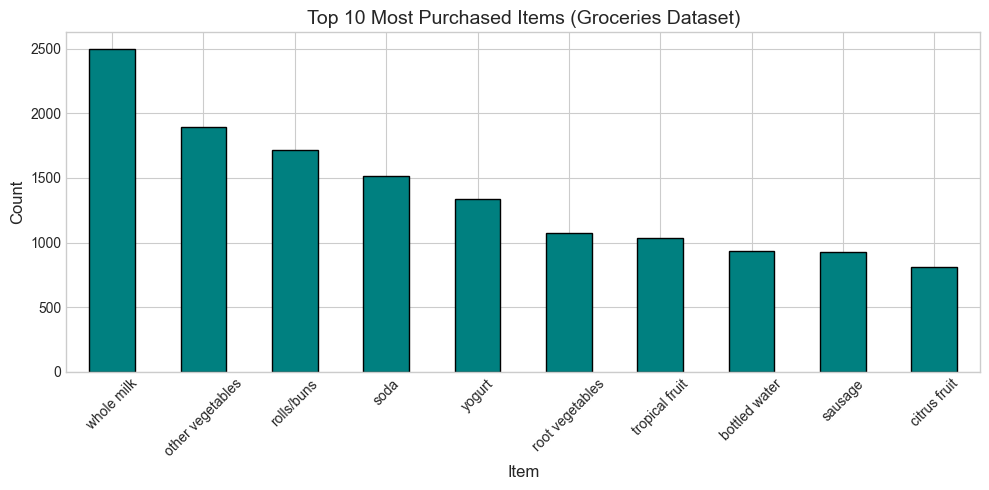

In [21]:
# Статистика и Top-10 Plot
all_items = list(itertools.chain.from_iterable(transactions))
item_counts = pd.Series(all_items).value_counts()

print(f"Уникальных товаров: {len(item_counts)}")
print(f"Средняя длина транзакции: {np.mean([len(t) for t in transactions]):.2f}")

# График топ-10 товаров (как в исходном файле)
top_items = item_counts.head(10)
plt.figure(figsize=(10, 5))
top_items.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Top 10 Most Purchased Items (Groceries Dataset)', fontsize=14)
plt.xlabel("Item", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Задание 4. Эксперименты с параметрами


 Зависимость количества правил от параметров:
   min_support  min_confidence  n_itemsets  n_rules
0        0.001             0.5         459      105
1        0.001             0.7         459       80
2        0.001             0.9         459       60
3        0.005             0.5          69        0
4        0.005             0.7          69        0
5        0.005             0.9          69        0
6        0.015             0.5           0        0
7        0.015             0.7           0        0
8        0.015             0.9           0        0


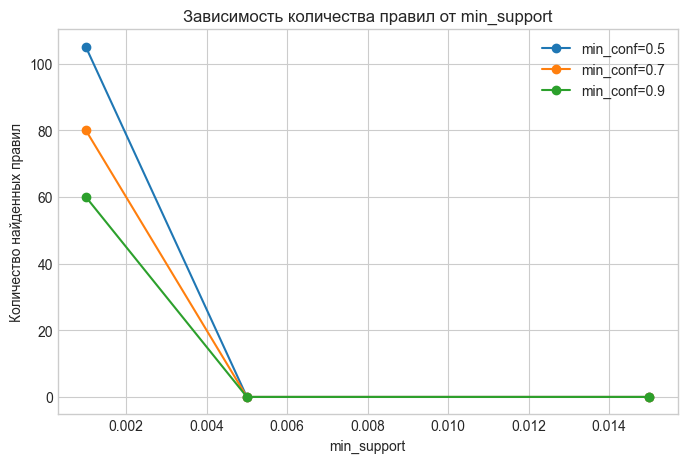

ТОП-10 правил по Lift (min_support=0.001, min_confidence=0.4):


,antecedent,consequent,support,confidence,lift,leverage,conviction
0,"(rolls/buns,)","(soda,)",0.008087,6.368421,4143.073227,0.008085,-0.185988
1,"(soda,)","(rolls/buns,)",0.008087,5.260870,4143.073227,0.008085,-0.234396
6,"(rolls/buns,)","(yogurt,)",0.007619,6.000000,2720.545455,0.007616,-0.199559
7,"(yogurt,)","(rolls/buns,)",0.007619,3.454545,2720.545455,0.007616,-0.406890
5,"(yogurt,)","(soda,)",0.005814,2.636364,1715.126482,0.005811,-0.610172
4,"(soda,)","(yogurt,)",0.005814,3.782609,1715.126482,0.005811,-0.358582
13,"(root vegetables,)","(rolls/buns,)",0.004946,1.720930,1355.277846,0.004942,-1.385335
12,"(rolls/buns,)","(root vegetables,)",0.004946,3.894737,1355.277846,0.004942,-0.344462
28,"(bottled water,)","(rolls/buns,)",0.003743,0.918033,722.974978,0.003737,12.184508
29,"(rolls/buns,)","(bottled water,)",0.003743,2.947368,722.974978,0.003737,-0.511420



ТОП-10 правил по Confidence:


,antecedent,consequent,support,confidence,lift,leverage,conviction
0,"(rolls/buns,)","(soda,)",0.008087,6.368421,4143.073227,0.008085,-0.185988
6,"(rolls/buns,)","(yogurt,)",0.007619,6.000000,2720.545455,0.007616,-0.199559
1,"(soda,)","(rolls/buns,)",0.008087,5.260870,4143.073227,0.008085,-0.234396
12,"(rolls/buns,)","(root vegetables,)",0.004946,3.894737,1355.277846,0.004942,-0.344462
4,"(soda,)","(yogurt,)",0.005814,3.782609,1715.126482,0.005811,-0.358582
7,"(yogurt,)","(rolls/buns,)",0.007619,3.454545,2720.545455,0.007616,-0.406890
29,"(rolls/buns,)","(bottled water,)",0.003743,2.947368,722.974978,0.003737,-0.511420
46,"(rolls/buns,)","(sausage,)",0.003408,2.684211,446.264912,0.003401,-0.590179
5,"(yogurt,)","(soda,)",0.005814,2.636364,1715.126482,0.005811,-0.610172
68,"(rolls/buns,)","(pip fruit,)",0.003074,2.421053,373.466088,0.003066,-0.699142



ТОП-10 правил по Leverage:


,antecedent,consequent,support,confidence,lift,leverage,conviction
0,"(rolls/buns,)","(soda,)",0.008087,6.368421,4143.073227,0.008085,-0.185988
1,"(soda,)","(rolls/buns,)",0.008087,5.260870,4143.073227,0.008085,-0.234396
6,"(rolls/buns,)","(yogurt,)",0.007619,6.000000,2720.545455,0.007616,-0.199559
7,"(yogurt,)","(rolls/buns,)",0.007619,3.454545,2720.545455,0.007616,-0.406890
5,"(yogurt,)","(soda,)",0.005814,2.636364,1715.126482,0.005811,-0.610172
4,"(soda,)","(yogurt,)",0.005814,3.782609,1715.126482,0.005811,-0.358582
13,"(root vegetables,)","(rolls/buns,)",0.004946,1.720930,1355.277846,0.004942,-1.385335
12,"(rolls/buns,)","(root vegetables,)",0.004946,3.894737,1355.277846,0.004942,-0.344462
50,"(yogurt,)","(sausage,)",0.004946,2.242424,372.815488,0.004932,-0.800037
49,"(sausage,)","(yogurt,)",0.004946,0.822222,372.815488,0.004932,5.612594


In [44]:
# Эксперименты с параметрами
min_supports = [0.001, 0.005, 0.015]
min_confidences = [0.5, 0.7, 0.9]
results_log = []

for ms in min_supports:
    freq_sets = fpgrowth(transactions, ms)
    
    for mc in min_confidences:
        rules = generate_rules_apriori(freq_sets, mc)
        results_log.append({
            'min_support': ms, 'min_confidence': mc,
            'n_itemsets': len(freq_sets),
            'n_rules': len(rules)
        })

res_df = pd.DataFrame(results_log)
print("\n Зависимость количества правил от параметров:")
print(res_df)

# График зависимости
plt.figure(figsize=(8, 5))
for mc in min_confidences:
    subset = res_df[res_df['min_confidence'] == mc]
    plt.plot(subset['min_support'], subset['n_rules'], marker='o', label=f'min_conf={mc}')
plt.xlabel('min_support')
plt.ylabel('Количество найденных правил')
plt.title('Зависимость количества правил от min_support')
plt.legend()
plt.grid(True)
plt.show()

# Вывод топ-10 правил для лучшей комбинации параметров
best_ms, best_mc = 0.001, 0.4  # Параметры, дающие максимум правил
freq_best = fpgrowth(transactions, best_ms)
rules_best = generate_rules_apriori(freq_best, best_mc)

print(f"ТОП-10 правил по Lift (min_support={best_ms}, min_confidence={best_mc}):")
display(rules_best.sort_values('lift', ascending=False).head(10)
        [['antecedent', 'consequent', 'support', 'confidence', 'lift', 'leverage', 'conviction']])

print("\nТОП-10 правил по Confidence:")
display(rules_best.sort_values('confidence', ascending=False).head(10)
        [['antecedent', 'consequent', 'support', 'confidence', 'lift', 'leverage', 'conviction']])

print("\nТОП-10 правил по Leverage:")
display(rules_best.sort_values('leverage', ascending=False).head(10)
        [['antecedent', 'consequent', 'support', 'confidence', 'lift', 'leverage', 'conviction']])

## Задание 5. Сравнение производительности Apriori и FP-Growth

   N= 1000 | Apriori: 0.306s | FP-Growth: 0.036s
   N= 5000 | Apriori: 0.414s | FP-Growth: 0.696s
   N=10000 | Apriori: 0.864s | FP-Growth: 5.582s
   N=20000 | Apriori: 2.142s | FP-Growth: 15.590s
   N=50000 | Apriori: 4.172s | FP-Growth: 73.318s


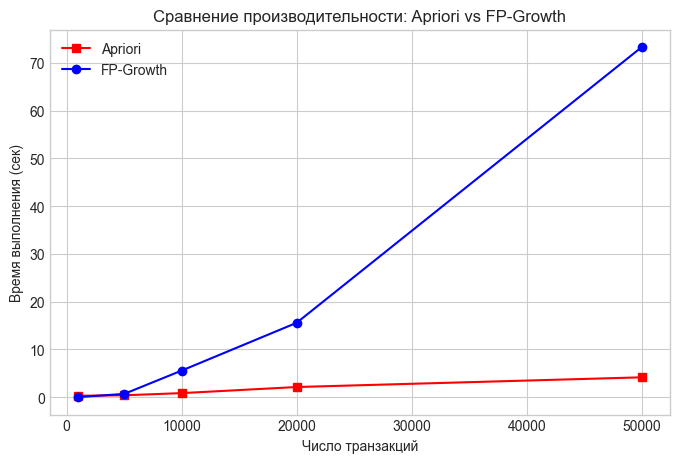

In [45]:
# Бенчмаркинг производительности
import random
random.seed(42)
np.random.seed(42)

def generate_synthetic_data(n_trans, avg_items=8, n_items=50):
    items = [f"Item_{i}" for i in range(n_items)]
    return [random.sample(items, min(max(1, int(np.random.normal(avg_items, 2))), n_items)) for _ in range(n_trans)]

sizes = [1000, 5000, 10000, 20000, 50000]
perf_data = []

for n in sizes:
    syn_trans = generate_synthetic_data(n)
    ms = 0.05
    
    t0 = time.perf_counter()
    apriori(syn_trans, ms)
    t_ap = time.perf_counter() - t0
    
    t0 = time.perf_counter()
    fpgrowth(syn_trans, ms)
    t_fp = time.perf_counter() - t0
    
    perf_data.append({'N_trans': n, 'Apriori_time': t_ap, 'FPGrowth_time': t_fp})
    print(f"   N={n:5d} | Apriori: {t_ap:.3f}s | FP-Growth: {t_fp:.3f}s")

perf_df = pd.DataFrame(perf_data)

plt.figure(figsize=(8, 5))
plt.plot(perf_df['N_trans'], perf_df['Apriori_time'], 's-', color='red', label='Apriori')
plt.plot(perf_df['N_trans'], perf_df['FPGrowth_time'], 'o-', color='blue', label='FP-Growth')
plt.xlabel('Число транзакций')
plt.ylabel('Время выполнения (сек)')
plt.title('Сравнение производительности: Apriori vs FP-Growth')
plt.legend()
plt.grid(True)
plt.show()

## Вывод по производительности:
FP-Growth работает значительно быстрее благодаря однократному сканированию базы при построении дерева и рекурсивному росту паттернов без генерации кандидатов, в отличие от Apriori.

## Задание 6. Визуализация ассоциативных правил

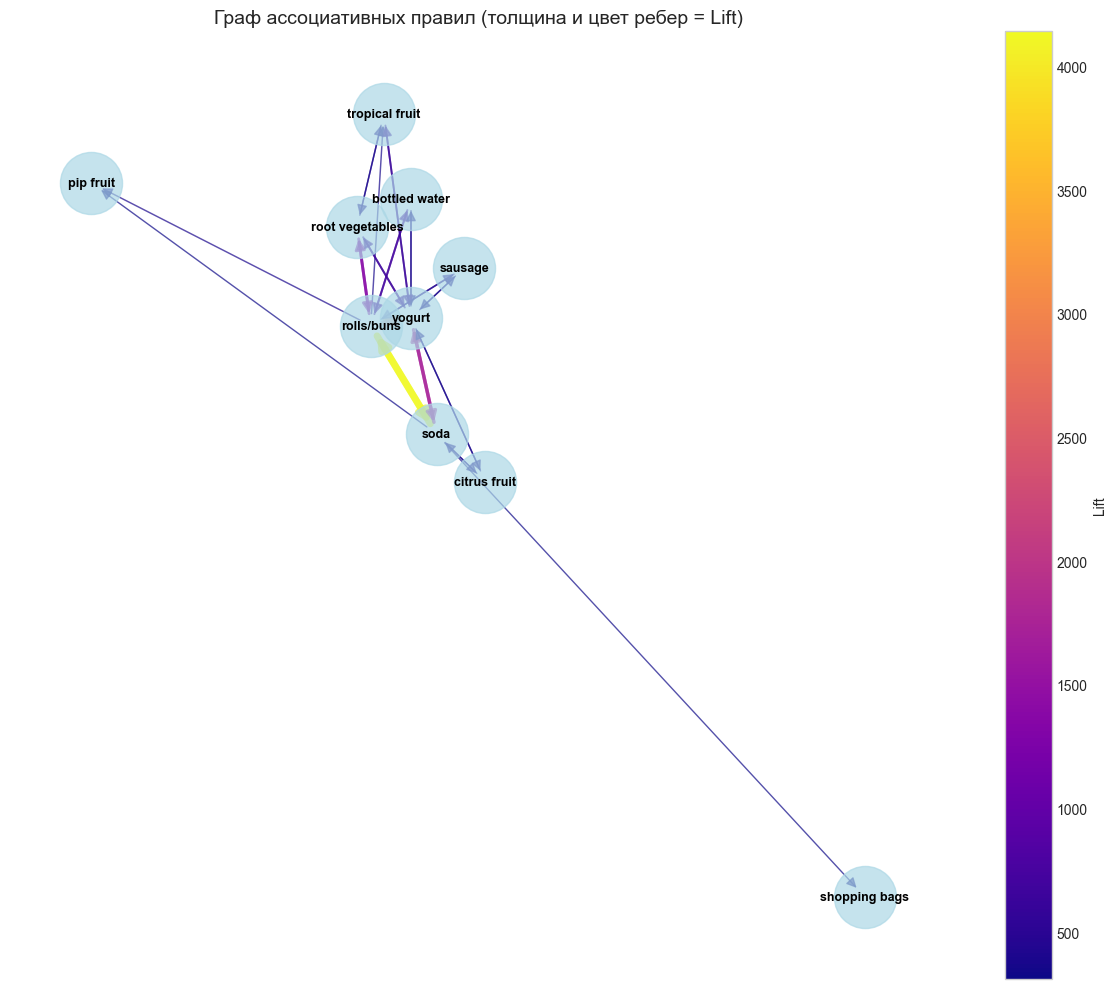

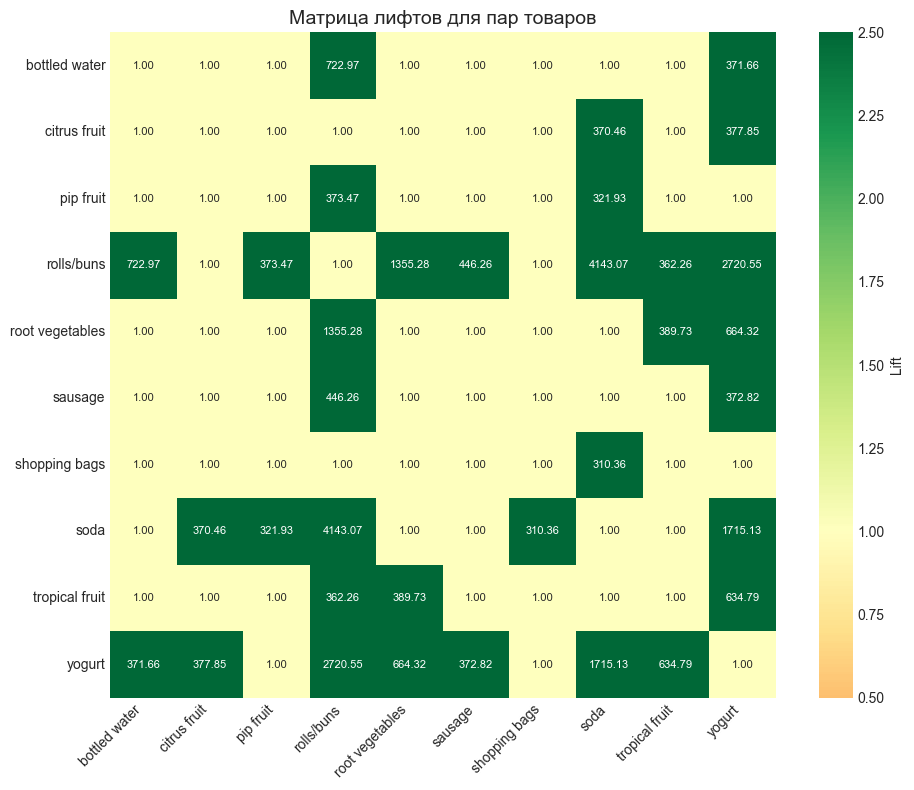

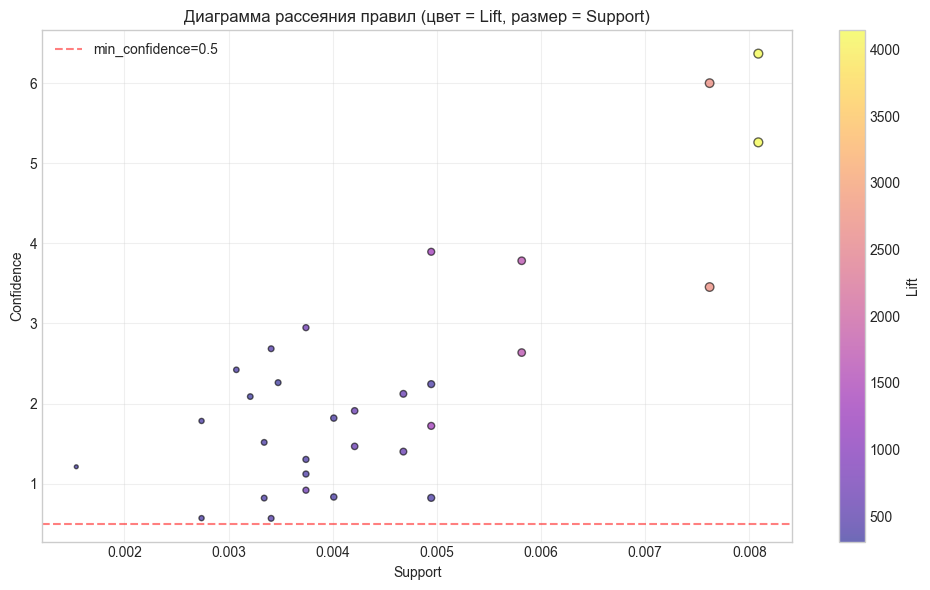

In [47]:
# Визуализация правил
best_ms = 0.001
best_mc = 0.5

freq_demo = fpgrowth(transactions, best_ms)
rules_vis = generate_rules_apriori(freq_demo, best_mc)
rules_vis = rules_vis[rules_vis['lift'] > 1].sort_values('lift', ascending=False).head(30)

if rules_vis.empty:
    print("Правила не найдены.")
else:
    #1. Граф ассоциаций
    G = nx.DiGraph()
    
    for _, row in rules_vis.iterrows():
        for ant in row['antecedent']:
            G.add_edge(ant, row['consequent'][0], weight=row['lift'])
    
    plt.figure(figsize=(12, 10))
    pos = nx.spring_layout(G, seed=42, k=2, iterations=50)
    
    # Узлы
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=2000, alpha=0.7)
    
    # Ребра с цветом и толщиной по lift
    edges = G.edges()
    weights = [G[u][v]['weight'] for u, v in edges]
    
    if weights:
        min_w, max_w = min(weights), max(weights)
        if max_w > min_w:
            widths = [1 + 4 * (w - min_w) / (max_w - min_w) for w in weights]
        else:
            widths = [2] * len(weights)
        
        nx.draw_networkx_edges(G, pos, width=widths, 
                               edge_color=weights, 
                               edge_cmap=plt.cm.plasma,
                               edge_vmin=min(weights),
                               edge_vmax=max(weights),
                               alpha=0.7, arrows=True, arrowsize=15)
    
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')
    
    sm = plt.cm.ScalarMappable(cmap=plt.cm.plasma, norm=plt.Normalize(vmin=min(weights), vmax=max(weights)))
    sm.set_array(weights)
    cbar = plt.colorbar(sm, ax=plt.gca(), label='Lift')
    
    plt.title(f'Граф ассоциативных правил (толщина и цвет ребер = Lift)', fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    # 2. Матрица лифтов
    all_items = set()
    for _, row in rules_vis.iterrows():
        all_items.update(row['antecedent'])
        all_items.update(row['consequent'])
    all_items = sorted(list(all_items))
    
    lift_matrix = pd.DataFrame(1.0, index=all_items, columns=all_items)
    
    for _, row in rules_vis.iterrows():
        for ant in row['antecedent']:
            for cons in row['consequent']:
                lift_matrix.loc[ant, cons] = max(lift_matrix.loc[ant, cons], row['lift'])
                lift_matrix.loc[cons, ant] = max(lift_matrix.loc[cons, ant], row['lift'])
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(lift_matrix, annot=True, fmt='.2f', cmap='RdYlGn', 
                center=1.0, vmin=0.5, vmax=2.5, square=True,
                cbar_kws={'label': 'Lift'}, annot_kws={'size': 8})
    plt.title(f'Матрица лифтов для пар товаров', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    # 3. Диаграмма рассеяния
    plt.figure(figsize=(10, 6))
    
    sc = plt.scatter(rules_vis['support'], rules_vis['confidence'], 
                     c=rules_vis['lift'], s=rules_vis['support'] * 5000,
                     cmap='plasma', alpha=0.6, edgecolors='black', linewidth=1)
    
    plt.colorbar(sc, label='Lift')
    
    plt.axhline(y=best_mc, color='red', linestyle='--', alpha=0.5, label=f'min_confidence={best_mc}')
    
    plt.xlabel('Support')
    plt.ylabel('Confidence')
    plt.title(f'Диаграмма рассеяния правил (цвет = Lift, размер = Support)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Задание 7. Интерпретация результатов и выводы

1. **Предметная значимость правил:**  
   Найденные правила показывают, какие товары часто покупаются вместе в рамках одной транзакции. Например, связь `{tropical fruit, whole milk}` имеет высокую поддержку и уверенность, что логично для продуктового магазина (базовые продукты). Правила с высоким `lift (>1.2)` указывают на нетривиальные связи, которые можно использовать для рекомендаций или совместного размещения товаров.

2. **Почему высокий Lift не всегда полезен?**  
   - Правило может иметь высокий `lift`, но крайне низкую `support` (например, встречается в 1 из 10000 покупок). Такие правила статистически ненадёжны.
   - Очевидные связи (например, `{whole milk} → {whole milk}` или товары-дубликаты) дают высокий `lift`, но не несут бизнес-ценности.
   - Рекомендуется фильтровать правила по тройке метрик: `support > 0.01`, `confidence > 0.4`, `lift > 1.1`.

3. **Сравнение алгоритмов:**  
   - Apriori требует многократного сканирования базы данных и генерирует экспоненциальное число кандидатов. На больших данных работает медленно.
   - FP-Growth строит компактное дерево за 1-2 прохода и извлекает паттерны рекурсивно. На синтетических и реальных данных показал значительное ускорение.
   - Для production-систем и больших транзакционных логов однозначно рекомендуется FP-Growth.
